EXPLORATORY DATA ANALYSIS

In [13]:
import pandas as pd 
import numpy as np
import sys, os
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


In [11]:
src_path = os.path.abspath("../src")
if src_path not in sys.path:
    sys.path.append(src_path)


SAMPLE_DIR = r"D:\projects\Healthcare\data\raw_sample"
from data_cleaning import clean_dataset

df_raw = pd.read_csv(os.path.join(SAMPLE_DIR, "stroke_sliced.csv"))
df, clean_report = clean_dataset(df_raw)

print("Cleaned data:", df.shape)
print("Columns:", df.columns.tolist())

2026-06-30 18:00:01,576 | data_cleaning | INFO | Cleaning started. Input shape: (15000, 22)
2026-06-30 18:00:01,848 | data_cleaning | INFO | Filled 'Symptoms' with mode (16.7% missing)
2026-06-30 18:00:02,049 | data_cleaning | INFO | Removed 0 duplicate rows
2026-06-30 18:00:02,100 | data_cleaning | INFO | Skipped 'Hypertension' for outliers (2 unique values)
2026-06-30 18:00:02,100 | data_cleaning | INFO | Skipped 'Heart Disease' for outliers (2 unique values)
2026-06-30 18:00:02,118 | data_cleaning | INFO | Skipped 'Stroke History' for outliers (2 unique values)
2026-06-30 18:00:02,134 | data_cleaning | INFO | Cleaning finished. Output shape: (15000, 22)


Cleaned data: (15000, 22)
Columns: ['Patient ID', 'Patient Name', 'Age', 'Gender', 'Hypertension', 'Heart Disease', 'Marital Status', 'Work Type', 'Residence Type', 'Average Glucose Level', 'Body Mass Index (BMI)', 'Smoking Status', 'Alcohol Intake', 'Physical Activity', 'Stroke History', 'Family History of Stroke', 'Dietary Habits', 'Stress Levels', 'Blood Pressure Levels', 'Cholesterol Levels', 'Symptoms', 'Diagnosis']


Statistical Summary

In [12]:
def statistical_summary(df):
    
    numeric_cols = df.select_dtypes(include="number").columns
    categorical_cols = df.select_dtypes(include="object").columns

    summary = {
        "numeric": df[numeric_cols].describe().T if len(numeric_cols) else None,
        "categorical": df[categorical_cols].describe().T if len(categorical_cols) else None,
        "n_numeric": len(numeric_cols),
        "n_categorical": len(categorical_cols),
    }
    return summary


summary = statistical_summary(df)

print(f"Numeric: {summary['n_numeric']}, Categorical: {summary['n_categorical']}\n")
print("=== NUMERIC SUMMARY ===")
print(summary["numeric"])
print("\n=== CATEGORICAL SUMMARY ===")
print(summary["categorical"])

Numeric: 8, Categorical: 14

=== NUMERIC SUMMARY ===
                         count          mean           std    min         25%  \
Patient ID             15000.0  49715.802867  29000.656642   1.00  24562.0000   
Age                    15000.0     54.035667     21.063111  18.00     36.0000   
Hypertension           15000.0      0.249000      0.432448   0.00      0.0000   
Heart Disease          15000.0      0.502933      0.500008   0.00      0.0000   
Average Glucose Level  15000.0    129.445209     40.487792  60.00     94.5175   
Body Mass Index (BMI)  15000.0     27.474302      7.230201  15.01     21.1600   
Stroke History         15000.0      0.500267      0.500017   0.00      0.0000   
Stress Levels          15000.0      5.022694      2.873223   0.00      2.5400   

                            50%         75%      max  
Patient ID             49448.00  75112.0000  99975.0  
Age                       54.00     72.0000     90.0  
Hypertension               0.00      0.0000      1.0

Target Distribution

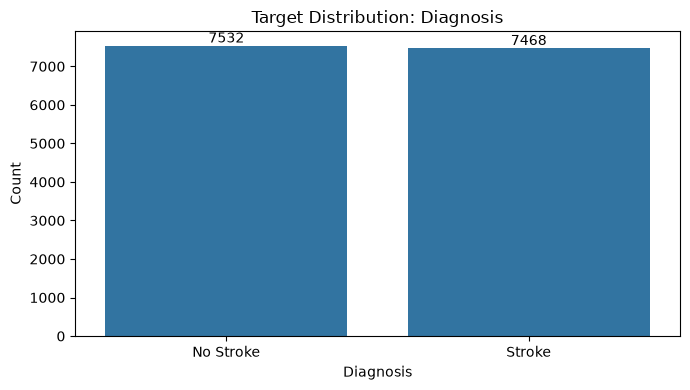

Class balance:
  No Stroke: 50.21%
  Stroke: 49.79%


In [14]:


def plot_target_distribution(df, target_col):
    """Plot the distribution of the target column."""
    fig, ax = plt.subplots(figsize=(7, 4))

    counts = df[target_col].value_counts()
    sns.barplot(x=counts.index.astype(str), y=counts.values, ax=ax)

    ax.set_title(f"Target Distribution: {target_col}")
    ax.set_xlabel(target_col)
    ax.set_ylabel("Count")

    # Add count labels on bars
    for i, v in enumerate(counts.values):
        ax.text(i, v, str(v), ha="center", va="bottom")

    plt.tight_layout()
    plt.show()

    # Print balance info
    pct = (counts / counts.sum() * 100).round(2)
    print("Class balance:")
    for cls, p in pct.items():
        print(f"  {cls}: {p}%")


plot_target_distribution(df, "Diagnosis")